# Model Evaluation and Error Analysis

## Objective

Evaluate the balanced Logistic Regression model beyond overall accuracy.

This notebook will:

- Create and interpret a confusion matrix
- Identify the most common category confusions
- Examine incorrectly classified tickets
- Document the model's strengths and weaknesses

In [1]:
from pathlib import Path

current_directory = Path.cwd()

print("Current working directory:")
print(current_directory)

Current working directory:
/Users/yogithagujjarlapudi/AI-ML Course/AI-ML-PROJECTS/AI-ML/Customer-Support-Ticket-Intelligence/notebooks


In [2]:
project_root = Path.cwd().parent

data_path = project_root / "data" / "processed" / "cleaned_tickets.csv"
model_path = project_root / "models" / "ticket_classifier.joblib"

print("Project root:", project_root)
print("Dataset exists:", data_path.exists())
print("Model exists:", model_path.exists())

Project root: /Users/yogithagujjarlapudi/AI-ML Course/AI-ML-PROJECTS/AI-ML/Customer-Support-Ticket-Intelligence
Dataset exists: True
Model exists: True


In [3]:
import pandas as pd

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

df.head()

Dataset shape: (11814, 2)

Column names:
['ticket_text', 'queue']


,ticket_text,queue
0,"Account Disruption Dear Customer Support Team,...",Technical Support
1,Inquiry Regarding Invoice Details Dear Custome...,Billing and Payments
2,"Feature Query Dear Customer Support,\n\nI hope...",Technical Support
3,Connectivity Problems with Printer on MacBook ...,Technical Support
4,"VPN Access Issue Customer Support,\n\nWe are e...",Product Support


In [4]:
#Recreate the original test set

from sklearn.model_selection import train_test_split

X = df["ticket_text"]
y = df["queue"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training tickets:", len(X_train))
print("Test tickets:", len(X_test))

Training tickets: 9451
Test tickets: 2363


In [5]:
#Load the saved model and generate predictions

import joblib
from sklearn.metrics import accuracy_score

loaded_model = joblib.load(model_path)

y_pred = loaded_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Number of predictions:", len(y_pred))
print(f"Test accuracy: {accuracy:.2%}")

Number of predictions: 2363
Test accuracy: 61.66%


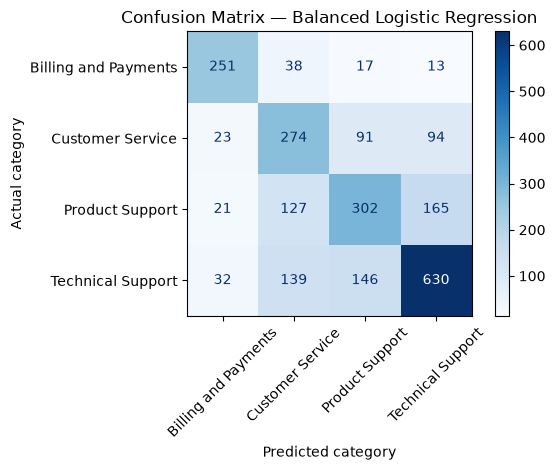

In [6]:
#Creating confusion matrix

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=loaded_model.classes_,
    cmap="Blues",
    xticks_rotation=45,
    values_format="d"
)

plt.title("Confusion Matrix — Balanced Logistic Regression")
plt.xlabel("Predicted category")
plt.ylabel("Actual category")
plt.tight_layout()
plt.show()

## Confusion Matrix Observations

- The model correctly classified 1,457 of 2,363 test tickets (61.66%).
- Billing and Payments performed best, with 251 of 319 tickets classified correctly.
- Product Support was the most difficult category, with 302 of 615 tickets classified correctly.
- The largest confusion was Product Support being predicted as Technical Support (165 tickets).
- Technical Support was also frequently confused with Product Support (146 tickets) and Customer Service (139 tickets).
- Billing and Payments appears easier to distinguish because billing-related vocabulary is more specific.
- The other three categories likely contain overlapping language and less clearly separated responsibilities.
- The diagonal contains - 251 + 274 + 302 + 630 = 1457 correct predictions
- 1457 / 2363 = 61.66%

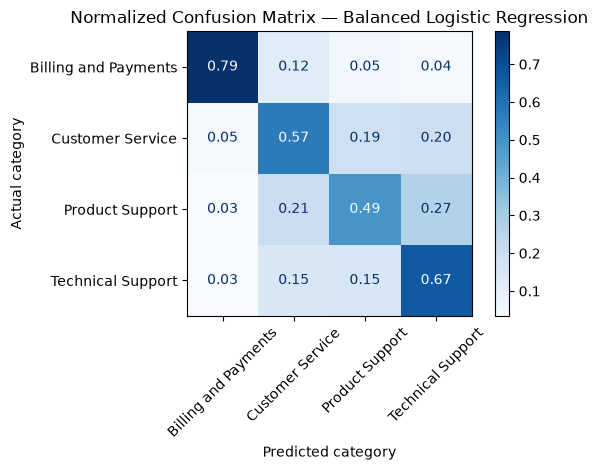

In [7]:
#Creating a normalized confusion matrix

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=loaded_model.classes_,
    normalize="true",
    cmap="Blues",
    xticks_rotation=45,
    values_format=".2f"
)

plt.title("Normalized Confusion Matrix — Balanced Logistic Regression")
plt.xlabel("Predicted category")
plt.ylabel("Actual category")
plt.tight_layout()
plt.show()

#### Normalized Confusion Matrix Findings

- Billing and Payments has the highest recall: 79%.
- Technical Support correctly identifies 67% of its actual tickets.
- Customer Service correctly identifies 57% of its actual tickets.
- Product Support has the lowest recall: 49%.
- The largest proportional error is Product Support → Technical Support at 27%.
- Customer Service, Product Support, and Technical Support appear to use overlapping vocabulary.
- Billing and Payments has more distinctive language than the other queues.

In [8]:
#Creating a misclassification table

import pandas as pd

evaluation_results = pd.DataFrame({
    "ticket_text": X_test.reset_index(drop=True),
    "actual_category": y_test.reset_index(drop=True),
    "predicted_category": y_pred
})

mistakes = evaluation_results[
    evaluation_results["actual_category"]
    != evaluation_results["predicted_category"]
].copy()

print("Total test tickets:", len(evaluation_results))
print("Correct predictions:", len(evaluation_results) - len(mistakes))
print("Incorrect predictions:", len(mistakes))
print(f"Error rate: {len(mistakes) / len(evaluation_results):.2%}")

Total test tickets: 2363
Correct predictions: 1457
Incorrect predictions: 906
Error rate: 38.34%


In [9]:
#Finding most common category confusions

common_confusions = (
    mistakes
    .groupby(["actual_category", "predicted_category"])
    .size()
    .reset_index(name="number_of_tickets")
    .sort_values("number_of_tickets", ascending=False)
    .reset_index(drop=True)
)

common_confusions

,actual_category,predicted_category,number_of_tickets
0,Product Support,Technical Support,165
1,Technical Support,Product Support,146
2,Technical Support,Customer Service,139
3,Product Support,Customer Service,127
4,Customer Service,Technical Support,94
5,Customer Service,Product Support,91
6,Billing and Payments,Customer Service,38
7,Technical Support,Billing and Payments,32
8,Customer Service,Billing and Payments,23
9,Product Support,Billing and Payments,21


In [10]:
#Inspecting the largest confusion

pd.set_option("display.max_colwidth", None)

product_as_technical = mistakes[
    (mistakes["actual_category"] == "Product Support")
    & (mistakes["predicted_category"] == "Technical Support")
]

print("Number of Product Support tickets predicted as Technical Support:")
print(len(product_as_technical))

product_as_technical[
    ["ticket_text", "actual_category", "predicted_category"]
].head(5)

Number of Product Support tickets predicted as Technical Support:
165


,ticket_text,actual_category,predicted_category
25,"Technical Support for System Glitches A significant problem has arisen, leading to integration failures. These issues might be due to recent updates that have introduced compatibility problems. Steps taken to resolve the issue, such as reverting updates and clearing the cache, have not resolved the problem. Assistance is required to address this issue.",Product Support,Technical Support
70,"Concerns Regarding Data Analytics Tool Performance To Customer Support, currently facing significant problems with the data analytics tool which is crucial for optimizing investments. The tool appears to be malfunctioning, possibly as a result of recent software updates. I have already attempted to restart the affected applications and clear the cache, but the issue remains unresolved. I kindly request that you address this matter urgently and provide a solution as soon as possible. If you need any additional information, please let us know. Thank you for your prompt attention.",Product Support,Technical Support
78,"Request for Assistance with OneNote I am experiencing recurrent crashes with Microsoft OneNote on my Windows 10 system. Even after reinstalling the application and clearing the cache, the problem continues. I suspect the issue might be caused by a corrupted cache or an outdated app version. I have attempted various troubleshooting methods, but the problem persists. Could you please help in resolving this issue? I would appreciate your guidance to get OneNote functioning smoothly again.",Product Support,Technical Support
84,"Data Analytics Disruption The data analytics disruption has impacted the investment optimization processes at the financial firm. The potential causes may include system overload or misconfiguration. After restarting the analytics servers and verifying the data feeds, the problem remains unresolved. We require assistance to resolve this issue.",Product Support,Technical Support
99,"Slow Query Performance in Database During data analytics processing, slow query performance was observed in the MySQL database.",Product Support,Technical Support


## Analysis of Product Support → Technical Support Errors

The largest confusion involved Product Support tickets being predicted as
Technical Support.

The reviewed tickets frequently contained technical language such as:

- system glitches
- integration failures
- software updates
- application crashes
- cache clearing
- server restarts
- database performance

The model's predictions appear understandable because these expressions are
strongly associated with technical troubleshooting.

This suggests:

1. Product Support and Technical Support have overlapping language.
2. The boundaries between the two queues may not be clearly defined.
3. Some dataset labels may be ambiguous or inconsistent.
4. Model errors can result from data quality and category definitions, not only
   from the classification algorithm.

In [11]:
#Inspecting the reverse confusion

technical_as_product = mistakes[
    (mistakes["actual_category"] == "Technical Support")
    & (mistakes["predicted_category"] == "Product Support")
]

print("Number of Technical Support tickets predicted as Product Support:")
print(len(technical_as_product))

technical_as_product[
    ["ticket_text", "actual_category", "predicted_category"]
].head(5)

Number of Technical Support tickets predicted as Product Support:
146


,ticket_text,actual_category,predicted_category
2,Support Request for Digital Strategy Enhancement Seeking assistance to improve digital strategies. Interested in utilizing Laravel 8 and Adobe Audition to boost brand growth and engagement. Could you provide guidance on getting started with the project?,Technical Support,Product Support
15,Request for Detailed Documentation on API Integration Capabilities for Project Management SaaS Is it possible to provide comprehensive documentation on the API integration capabilities for our project management SaaS? I need to understand how to integrate the API into our existing system.,Technical Support,Product Support
32,"Dear Customer Support, we have noted a considerable decrease in our online engagement metrics over the past week. This may be due to recent algorithm changes on social media platforms. We have attempted to adjust our content strategy, which has shown some improvements, but we are still closely monitoring the situation as it concerns our business. We would greatly appreciate your guidance and support to help us better understand and address this issue. Please let us know if there is any additional information needed.",Technical Support,Product Support
67,"Problem with Underwhelming Marketing Agency Campaigns Our digital marketing campaigns managed by the agency are not performing well despite recent strategy modifications. We suspect that recent algorithm updates on the platform might be influencing results. We have attempted to optimize content and refine ad targeting, which has yielded some progress. We would appreciate guidance on how to get our campaigns back on track.",Technical Support,Product Support
71,"Request for Security Improvements Dear Customer Support, I am writing to request the enhancement of security protocols for managing medical data in our hospital systems. Ensuring compliance with data protection regulations is crucial for the healthcare industry. I would like to propose the implementation of advanced encryption methods, secure data storage, and regular security audits to prevent data breaches. Additionally, I believe that providing training to hospital staff on data handling and security practices would be beneficial. I am confident that these measures will help protect our data.",Technical Support,Product Support


## Reverse Confusion Findings

Technical Support was predicted as Product Support for 146 tickets.

Several reviewed tickets request documentation, guidance, product capabilities,
feature improvements, or instructions for getting started. This language can
reasonably resemble Product Support even when the dataset labels the ticket as
Technical Support.

The examples indicate that:

- Product Support and Technical Support have overlapping vocabulary.
- Some tickets contain both product-related and technical concepts.
- The distinction between the two queues may not be clearly defined.
- Some dataset labels may be ambiguous or inconsistent.
- Improving label definitions and training-data quality could improve the model.

In [12]:
#Comparing confidence for correct and incorrect predictions

prediction_probabilities = loaded_model.predict_proba(X_test)
prediction_confidence = prediction_probabilities.max(axis=1)

confidence_analysis = pd.DataFrame({
    "ticket_text": X_test.to_numpy(),
    "actual_category": y_test.to_numpy(),
    "predicted_category": y_pred,
    "confidence": prediction_confidence
})

confidence_analysis["correct"] = (
    confidence_analysis["actual_category"]
    == confidence_analysis["predicted_category"]
)

confidence_analysis.groupby("correct")["confidence"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
correct,,,
False,906,0.456223,0.439714
True,1457,0.582250,0.539395


### This is a useful result:
- Incorrect predictions had an average confidence of 45.62%.
- Correct predictions had an average confidence of 58.23%.
- Correct predictions also had a higher median confidence: 53.94% versus 43.97%.
So, higher confidence is associated with better predictions. However, the scores still overlap, so confidence alone cannot guarantee correctness.

In [13]:
#Evaluating the 60% review threshold

confidence_threshold = 0.60

automatic_tickets = confidence_analysis[
    confidence_analysis["confidence"] >= confidence_threshold
]

manual_review_tickets = confidence_analysis[
    confidence_analysis["confidence"] < confidence_threshold
]

automatic_accuracy = automatic_tickets["correct"].mean()
automatic_coverage = len(automatic_tickets) / len(confidence_analysis)

print("Automatically classified tickets:", len(automatic_tickets))
print("Manual-review tickets:", len(manual_review_tickets))
print(f"Automatic coverage: {automatic_coverage:.2%}")
print(f"Accuracy on automatic tickets: {automatic_accuracy:.2%}")

Automatically classified tickets: 627
Manual-review tickets: 1736
Automatic coverage: 26.53%
Accuracy on automatic tickets: 86.60%


## Confidence-Threshold Findingshold Findings

Using a 60% confidence threshold:

- 627 of 2,363 test tickets would be classified automatically.
- 1,736 tickets would be sent for manual review.
- Automatic coverage is 26.53%.
- Accuracy among automatically classified tickets is 86.60%.
- This is substantially higher than the model's overall accuracy of 61.66%.

The threshold demonstrates a tradeoff between automation and reliability. The
model can make fewer, more reliable automatic decisions while sending uncertain
tickets to a support agent.